# Layer 22 channel summaries

Продолжение `patch_spread_zigzag_metrics.ipynb` и `patch_success_analysis_soft_metrics.ipynb`: суммарная важность каналов и суммарные дельты на `model.22` для 200 картинок (100 success / 100 fail).

In [1]:
from pathlib import Path
import sys

_nb_cwd = Path.cwd()
if (_nb_cwd / "new_experiments" / "patch_success_analysis").exists():
    sys.path.insert(0, str(_nb_cwd / "new_experiments"))
elif (_nb_cwd / "patch_success_analysis").exists():
    sys.path.insert(0, str(_nb_cwd))
else:
    raise RuntimeError(f"Unexpected cwd={_nb_cwd}; run from repo root or new_experiments")

import matplotlib.pyplot as plt
import pandas as pd

from patch_success_analysis.channel_metrics import (
    channel_summary_frame,
    compute_or_load_channel_summary,
    plot_channel_summary_grid,
    select_balanced_examples,
)
from patch_success_analysis.notebook_setup import (
    ensure_new_experiments_cwd,
    make_coco_people_patch_success_experiment,
)

layer_name = "model.22"
analysis_examples_per_class = 3000
force_channel_summary_recompute = False

cwd = ensure_new_experiments_cwd()
attack_config, config, exp = make_coco_people_patch_success_experiment(target_layer=layer_name)
cache = exp.build_or_load_cache(force=False)
selected_examples = select_balanced_examples(exp, per_class=analysis_examples_per_class)

print(f"cwd={cwd}")
print(f"attack cache key={attack_config.cache_key()}")
print(f"attack cache path={attack_config.cache_path}")
print(
    f"selected={len(selected_examples)} "
    f"({sum(e.success for e in selected_examples)} success / {sum(not e.success for e in selected_examples)} fail)"
)


cwd=/Users/ashentide/PycharmProjects/PatchSuccessResearch/new_experiments
attack cache key=e91cdfc4a2c4e20d
attack cache path=new_experiments/outputs/patch_success_analysis/cache/attack_pool_e91cdfc4a2c4e20d.pkl
selected=5300 (2650 success / 2650 fail)


In [2]:
summary = compute_or_load_channel_summary(
    exp,
    selected_examples,
    layer_name=layer_name,
    force=force_channel_summary_recompute,
)
examples_df = pd.DataFrame(summary["examples"])
display(examples_df.groupby("success")[["drop", "layer_maps_loaded_from_cache"]].agg({
    "drop": ["count", "mean", "std"],
    "layer_maps_loaded_from_cache": "mean",
}))
print(f"channel summary cache: {summary['cache_path']}")
print(f"loaded_from_cache={summary['loaded_from_cache']}")


drop                     layer_maps_loaded_from_cache
        count      mean       std                         mean
success                                                       
False    2646  0.117636  0.115719                          1.0
True     2650  0.711765  0.199495                          1.0

channel summary cache: new_experiments/outputs/patch_success_analysis/cache/channel_summary_dd02dc3c8554b088.pkl
loaded_from_cache=True


## Unsigned

Importance is `sum(abs(SegmentIG[0;0.1]))` per channel; delta is `sum(abs(patched_activation - clean_activation))` per channel. In the sorted row, both panels use descending unsigned importance order.

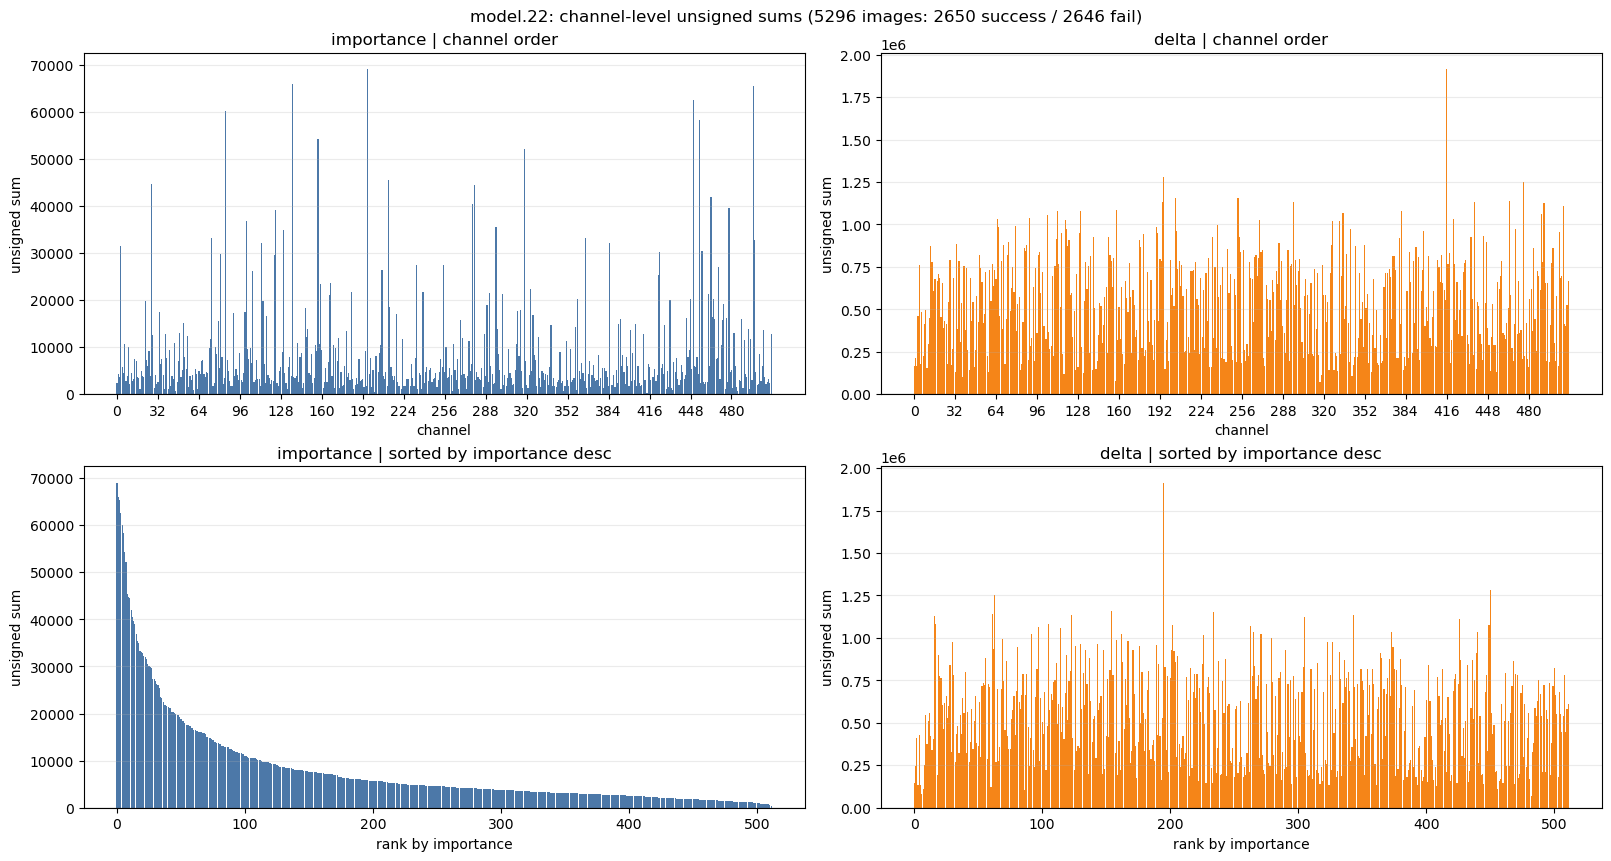

new_experiments/outputs/patch_success_analysis/figures/channel_summary_model_22_unsigned_200.png


,rank,channel,importance_sum,delta_sum
0,1,196,69032.018890,1.471147e+05
1,2,137,65995.918699,2.430858e+05
2,3,497,65402.096607,4.106249e+05
3,4,450,62557.994406,1.363720e+05
4,5,85,60120.936697,4.282419e+05
5,6,455,58324.697098,1.332497e+05
6,7,157,54247.454380,8.102925e+04
7,8,318,52096.675853,1.113528e+05
8,9,212,45418.352205,2.540516e+05
9,10,27,44751.231754,5.431620e+05


In [3]:
fig = plot_channel_summary_grid(summary, variant="unsigned")
unsigned_fig_path = exp.figures_dir / "channel_summary_model_22_unsigned_200.png"
fig.savefig(unsigned_fig_path, dpi=160, bbox_inches="tight")
plt.show()
print(unsigned_fig_path)

unsigned_sorted = channel_summary_frame(summary, variant="unsigned", sorted_by_importance=True)
display(unsigned_sorted.head(20))


## Signed

Importance is `sum(SegmentIG[0;0.1])` per channel; delta is `sum(patched_activation - clean_activation)` per channel. In the sorted row, both panels use descending signed importance order.

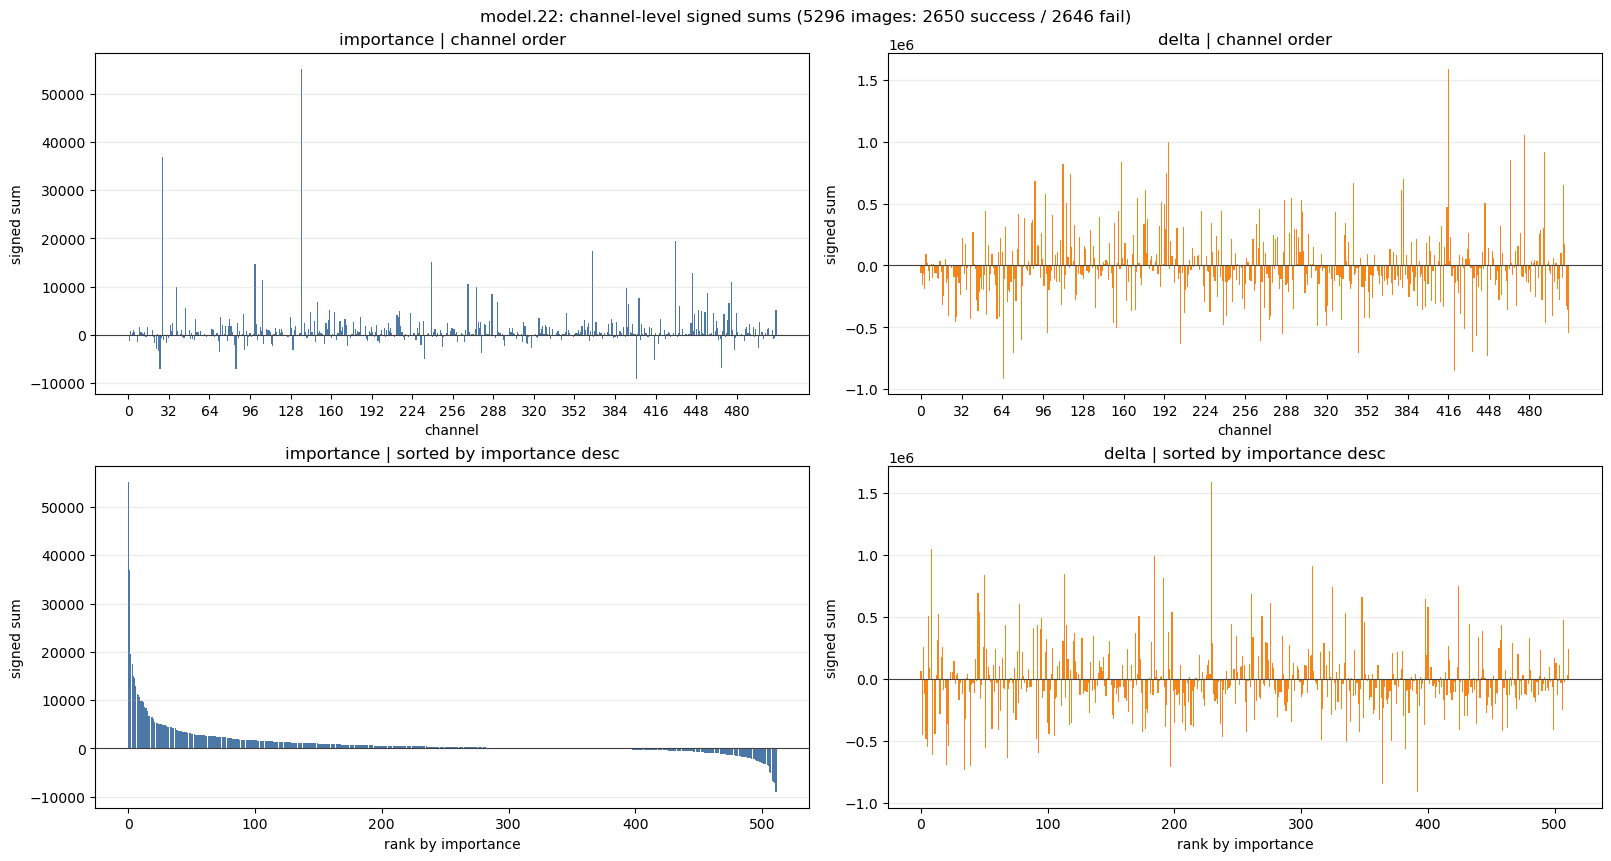

new_experiments/outputs/patch_success_analysis/figures/channel_summary_model_22_signed_200.png


,rank,channel,importance_sum,delta_sum
0,1,137,55179.530000,6.246718e+04
1,2,27,36942.654515,-4.532674e+05
2,3,432,19565.315018,2.608293e+05
3,4,366,17459.306126,-1.241212e+05
4,5,239,15051.811937,-4.825321e+05
5,6,100,14616.202620,-5.487785e+05
6,7,445,12888.144666,5.046216e+05
7,8,106,11316.557068,8.752302e+04
8,9,476,11015.219009,1.052627e+06
9,10,268,10645.005963,-6.138256e+05


In [4]:
fig = plot_channel_summary_grid(summary, variant="signed")
signed_fig_path = exp.figures_dir / "channel_summary_model_22_signed_200.png"
fig.savefig(signed_fig_path, dpi=160, bbox_inches="tight")
plt.show()
print(signed_fig_path)

signed_sorted = channel_summary_frame(summary, variant="signed", sorted_by_importance=True)
display(signed_sorted.head(20))


## Channel 137 overlays

Канал `137` сильнее всего выделяется в суммарной importance. Ниже берем 5 изображений с максимальной `sum(abs(importance_channel_137))` и накладываем channel map на clean letterboxed image.

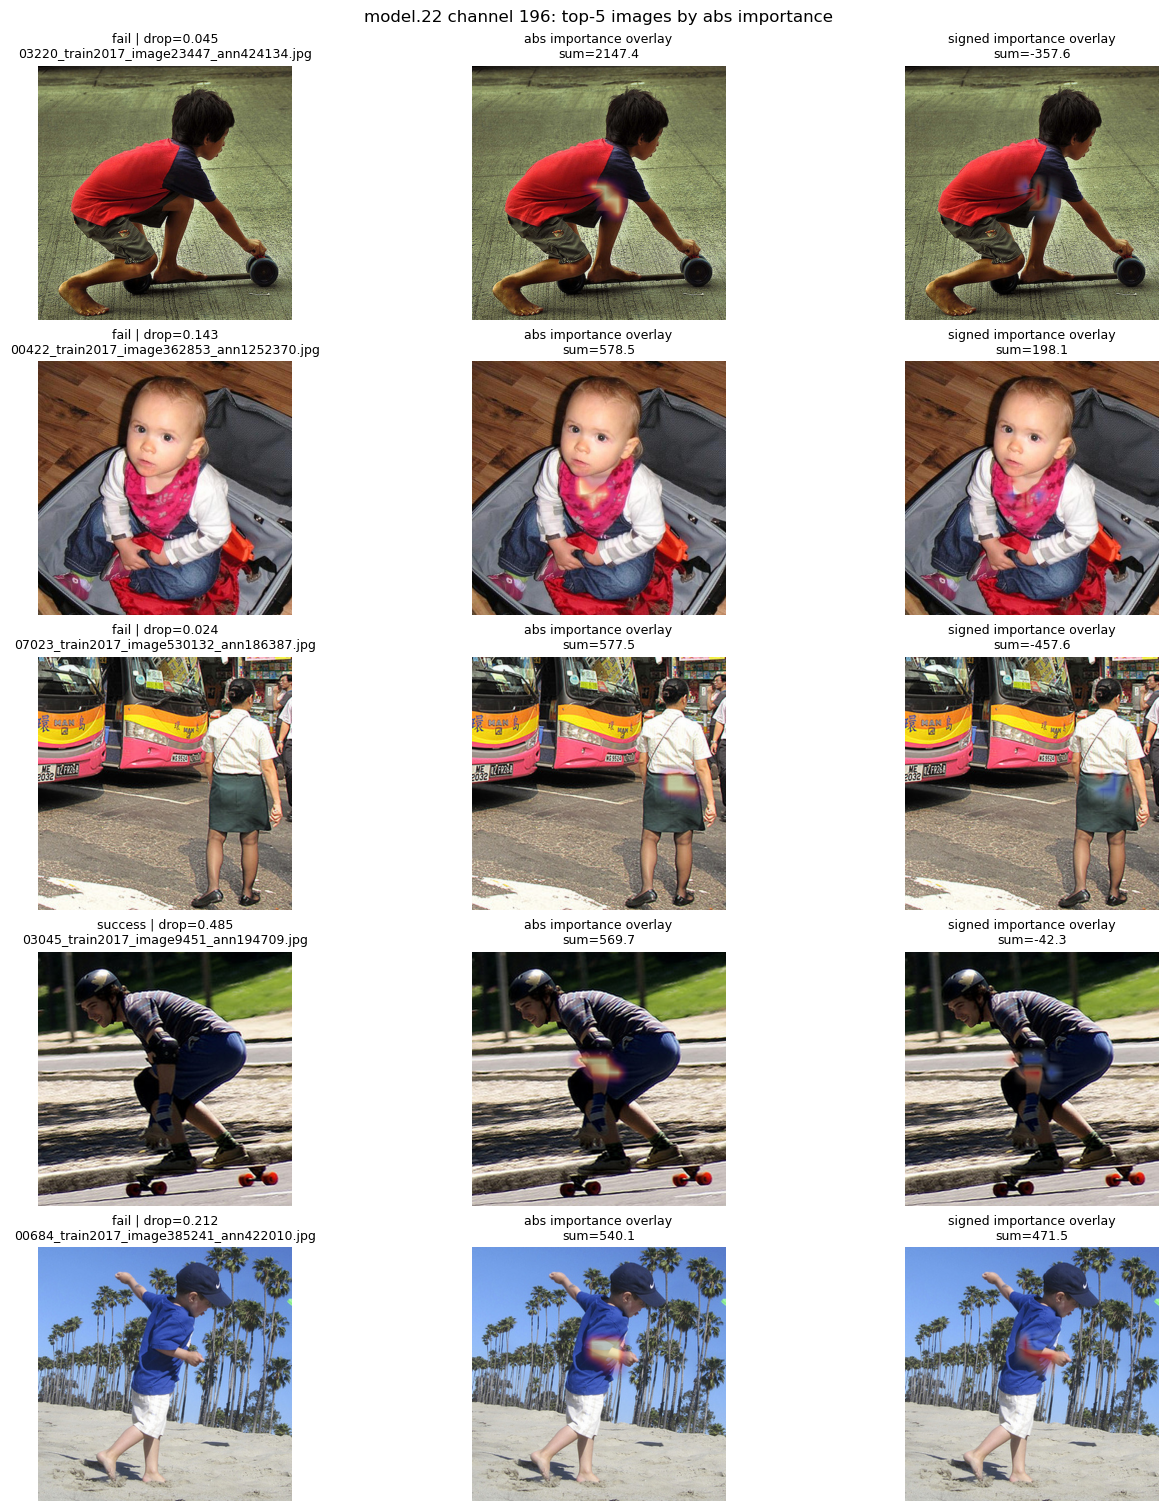

new_experiments/outputs/patch_success_analysis/figures/channel_196_importance_overlay_top5.png
overlay skipped=4


,path,success,drop,channel,importance_abs_sum,importance_signed_sum,delta_abs_sum,delta_signed_sum,layer_maps_cache_path
0,../datasets/COCO_people/03220_train2017_image2...,False,0.044762,196,2147.397398,-357.634098,21.552316,-4.784735,new_experiments/outputs/patch_success_analysis...
1,../datasets/COCO_people/00422_train2017_image3...,False,0.143246,196,578.525426,198.082530,35.542904,-3.707474,new_experiments/outputs/patch_success_analysis...
2,../datasets/COCO_people/07023_train2017_image5...,False,0.023782,196,577.525645,-457.633517,28.340320,-10.349782,new_experiments/outputs/patch_success_analysis...
3,../datasets/COCO_people/03045_train2017_image9...,True,0.485435,196,569.653850,-42.326198,21.212795,-5.530576,new_experiments/outputs/patch_success_analysis...
4,../datasets/COCO_people/00684_train2017_image3...,False,0.211599,196,540.060511,471.526148,26.572775,-10.783754,new_experiments/outputs/patch_success_analysis...


In [5]:
from patch_success_analysis.channel_metrics import plot_channel_importance_overlays

outlier_channel = int(unsigned_sorted.iloc[0]["channel"])
fig, channel137_top5 = plot_channel_importance_overlays(
    exp,
    selected_examples,
    layer_name=layer_name,
    channel=outlier_channel,
    max_examples=5,
)
overlay_fig_path = exp.figures_dir / f"channel_{outlier_channel}_importance_overlay_top5.png"
fig.savefig(overlay_fig_path, dpi=160, bbox_inches="tight")
plt.show()
print(overlay_fig_path)
print(f"overlay skipped={channel137_top5.attrs.get('n_skipped', 0)}")
display(channel137_top5)


## Ranked neuron deltas and spiral spread

Дальше работаем уже не с агрегированными каналами, а с нейронами внутри выбранных top-channel subsets: top 1%, top 10% и все каналы. В ranked-neuron графике первые три строки показывают signed delta, следующие три строки показывают `mean(abs(delta))` по примерам для каждого нейрона. Для спирали сверху остаются старые delta-графики со std-заливками, ниже те же delta-кривые без дисперсий плюс importance для того же обхода.

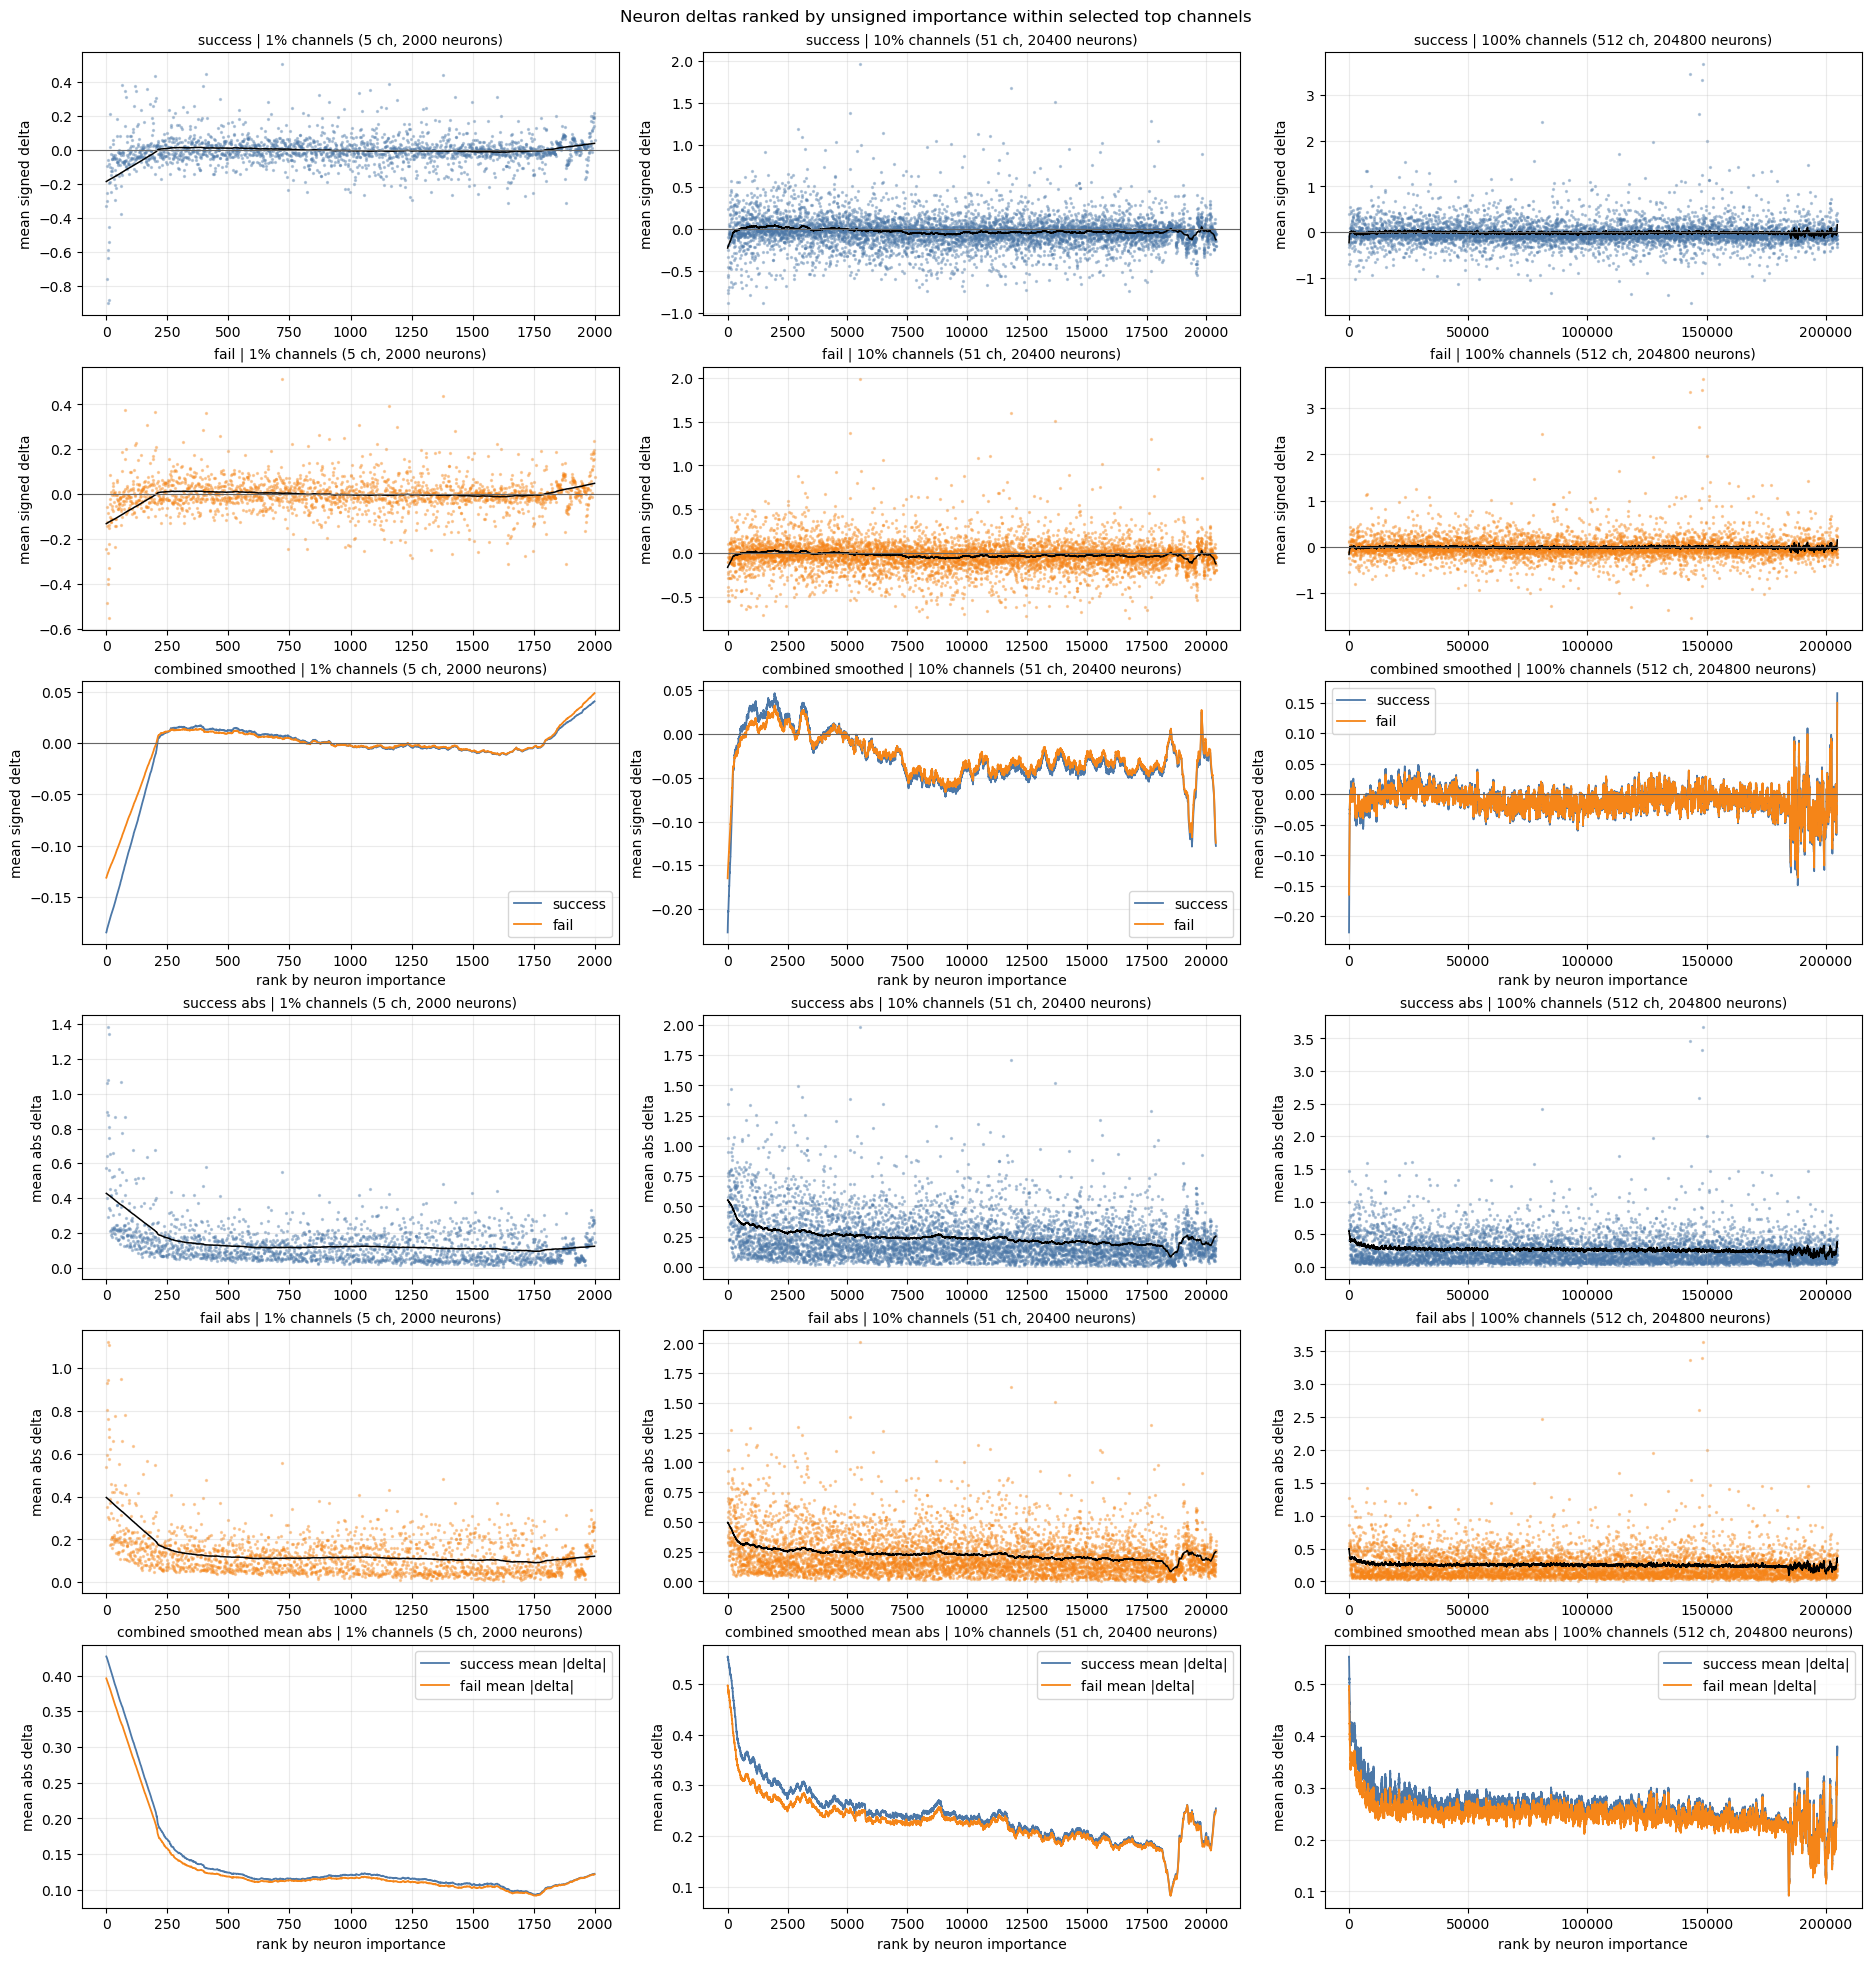

ranked neuron cache: new_experiments/outputs/patch_success_analysis/cache/ranked_neuron_delta_abs_v2_7e9449646189f893.pkl
loaded_from_cache=True
new_experiments/outputs/patch_success_analysis/figures/ranked_neuron_delta_top_channels_model_22.png


: 

In [ ]:
import importlib
import patch_success_analysis.channel_metrics as channel_metrics

channel_metrics = importlib.reload(channel_metrics)

channel_fractions = (1, 10, 100)
force_ranked_neuron_delta_recompute = False

ranked_result = channel_metrics.compute_or_load_ranked_neuron_delta_by_channel_fraction(
    exp,
    summary,
    selected_examples,
    fractions=channel_fractions,
    force=force_ranked_neuron_delta_recompute,
)
fig = channel_metrics.plot_ranked_neuron_delta_by_channel_fraction(ranked_result["ranked"], smooth_window=401)
ranked_fig_path = exp.figures_dir / "ranked_neuron_delta_top_channels_model_22.png"
fig.savefig(ranked_fig_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"ranked neuron cache: {ranked_result['cache_path']}")
print(f"loaded_from_cache={ranked_result['loaded_from_cache']}")
print(ranked_fig_path)
